In [1]:
# Install required packages
!pip install transformers datasets accelerate scikit-learn matplotlib seaborn pandas numpy torch --quiet

Import Libraries

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForQuestionAnswering,
    TrainingArguments,
    Trainer,
    default_data_collator,
    pipeline
)
from datasets import load_dataset, Dataset, DatasetDict
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check device availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Load and Explore Dataset

In [3]:
# Load the COVID-QA dataset from HuggingFace
dataset = load_dataset("deepset/covid_qa_deepset")

print("Dataset Structure:")
print(dataset)
print("\nDataset Features:")
print(dataset['train'].features)

# Display sample examples
print("\n=== Sample Example ===")
sample = dataset['train'][0]
for key, value in sample.items():
    print(f"\n{key}:")
    print(value if len(str(value)) < 500 else str(value)[:500] + '...')

Dataset Structure:
DatasetDict({
    train: Dataset({
        features: ['document_id', 'context', 'question', 'is_impossible', 'id', 'answers'],
        num_rows: 2019
    })
})

Dataset Features:
{'document_id': Value('int32'), 'context': Value('string'), 'question': Value('string'), 'is_impossible': Value('bool'), 'id': Value('int32'), 'answers': {'text': List(Value('string')), 'answer_start': List(Value('int32'))}}

=== Sample Example ===

document_id:
630

context:
Functional Genetic Variants in DC-SIGNR Are Associated with Mother-to-Child Transmission of HIV-1

https://www.ncbi.nlm.nih.gov/pmc/articles/PMC2752805/

Boily-Larouche, Geneviève; Iscache, Anne-Laure; Zijenah, Lynn S.; Humphrey, Jean H.; Mouland, Andrew J.; Ward, Brian J.; Roger, Michel
2009-10-07
DOI:10.1371/journal.pone.0007211
License:cc-by

Abstract: BACKGROUND: Mother-to-child transmission (MTCT) is the main cause of HIV-1 infection in children worldwide. Given that the C-type lectin recep...

question:
What is th

Dataset Statistics

In [4]:
# Dataset statistics
def analyze_dataset(dataset_split):
    """Analyze dataset statistics"""
    df = pd.DataFrame(dataset_split)

    # Question length statistics
    df['question_length'] = df['question'].apply(len)
    df['context_length'] = df['context'].apply(len) if 'context' in df.columns else df['document_text'].apply(len)

    print(f"\nTotal examples: {len(df)}")
    print(f"\nQuestion length stats:")
    print(df['question_length'].describe())
    print(f"\nContext length stats:")
    print(df['context_length'].describe())

    return df

# Analyze training set
train_df = analyze_dataset(dataset['train'])


Total examples: 2019

Question length stats:
count    2019.000000
mean       58.485884
std        25.181879
min        11.000000
25%        39.000000
50%        55.000000
75%        73.000000
max       194.000000
Name: question_length, dtype: float64

Context length stats:
count     2019.000000
mean     32051.449232
std      17353.239590
min       2876.000000
25%      17840.000000
50%      29857.000000
75%      42753.000000
max      70846.000000
Name: context_length, dtype: float64


Initialize Tokenizer

In [5]:
# Initialize tokenizer
model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)

# Configuration for preprocessing
max_length = 384  # Maximum sequence length
doc_stride = 128  # Stride for splitting long documents

print(f"Tokenizer loaded: {model_name}")
print(f"Vocabulary size: {tokenizer.vocab_size}")
print(f"Max length: {max_length}")
print(f"Doc stride: {doc_stride}")

Tokenizer loaded: distilbert-base-uncased
Vocabulary size: 30522
Max length: 384
Doc stride: 128


Preprocess Training Samples

In [6]:
def preprocess_training_examples(examples):
    """
    Preprocess training examples for DistilBERT QA

    This function:
    1. Tokenizes questions and contexts
    2. Maps character-level answer positions to token positions
    3. Handles cases where answer is not in the truncated context
    """
    # Prepare questions and contexts
    questions = [q.strip() for q in examples["question"]]
    contexts = examples["context"] if "context" in examples else examples["document_text"]

    # Tokenize with truncation and padding
    inputs = tokenizer(
        questions,
        contexts,
        max_length=max_length,
        truncation="only_second",  # Only truncate context, not question
        return_offsets_mapping=True,
        padding="max_length",
    )

    # Get offset mapping to map tokens back to character positions
    offset_mapping = inputs.pop("offset_mapping")

    # Process answers
    answers = examples["answers"] if "answers" in examples else examples["answer"]

    start_positions = []
    end_positions = []

    for i, (offset, answer) in enumerate(zip(offset_mapping, answers)):
        # Get sequence ids to identify question vs context tokens
        sequence_ids = inputs.sequence_ids(i)

        # Find context start and end indices
        try:
            context_start = sequence_ids.index(1)
            context_end = len(sequence_ids) - 1 - sequence_ids[::-1].index(1)
        except ValueError:
            # No context tokens found
            start_positions.append(0)
            end_positions.append(0)
            continue

        # Handle different answer formats
        if isinstance(answer, dict):
            # SQuAD format
            if len(answer["text"]) == 0:
                start_positions.append(0)
                end_positions.append(0)
                continue
            start_char = answer["answer_start"][0]
            end_char = start_char + len(answer["text"][0])
        elif isinstance(answer, list) and len(answer) > 0:
            # List format with text and answer_start
            if isinstance(answer[0], dict):
                start_char = answer[0].get("answer_start", 0)
                end_char = start_char + len(answer[0].get("text", ""))
            else:
                start_char = answer[0].get("answer_start", 0) if isinstance(answer[0], dict) else 0
                end_char = start_char + len(str(answer[0]))
        else:
            # Simple text format
            answer_text = str(answer) if not isinstance(answer, list) else str(answer[0])
            context_text = contexts[i]
            start_char = context_text.find(answer_text)
            end_char = start_char + len(answer_text) if start_char >= 0 else 0

        # Check if answer is within the truncated context
        if start_char == -1 or offset[context_start][0] > end_char or offset[context_end][1] < start_char:
            # Answer not in truncated context
            start_positions.append(0)
            end_positions.append(0)
        else:
            # Find token positions for answer span
            # Find start token position
            idx = context_start
            while idx <= context_end and offset[idx][0] <= start_char:
                idx += 1
            start_positions.append(idx - 1)

            # Find end token position
            idx = context_end
            while idx >= context_start and offset[idx][1] >= end_char:
                idx -= 1
            end_positions.append(idx + 1)

    inputs["start_positions"] = start_positions
    inputs["end_positions"] = end_positions

    return inputs

# Apply preprocessing to the dataset
print("Preprocessing training data...")
tokenized_datasets = dataset.map(
    preprocess_training_examples,
    batched=True,
    remove_columns=dataset["train"].column_names,
    desc="Running tokenizer",
)

print(f"\nPreprocessing complete!")
print(f"Train samples: {len(tokenized_datasets['train'])}")
if 'validation' in tokenized_datasets:
    print(f"Validation samples: {len(tokenized_datasets['validation'])}")

Preprocessing training data...

Preprocessing complete!
Train samples: 2019


Load Model

In [7]:
# Load pretrained DistilBERT for Question Answering
model = DistilBertForQuestionAnswering.from_pretrained(model_name)

# Move model to device
model = model.to(device)

print(f"Model loaded: {model_name}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Model architecture summary
print("\nModel Architecture:")
print(model)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForQuestionAnswering LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
qa_outputs.weight       | MISSING    | 
qa_outputs.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded: distilbert-base-uncased
Total parameters: 66,364,418
Trainable parameters: 66,364,418

Model Architecture:
DistilBertForQuestionAnswering(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((76

Training Configuration

In [8]:
# Training configuration
training_args = TrainingArguments(
    output_dir="./covid-qa-distilbert-results",
    eval_strategy="epoch",
    learning_rate=3e-5,  # Fine-tuning learning rate
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,  # Number of training epochs
    weight_decay=0.01,
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    logging_dir="./logs",
    logging_steps=100,
    seed=42,
    fp16=torch.cuda.is_available(),  # Use mixed precision if GPU available
)

print("Training Arguments:")
print(f"  Learning rate: {training_args.learning_rate}")
print(f"  Batch size: {training_args.per_device_train_batch_size}")
print(f"  Epochs: {training_args.num_train_epochs}")
print(f"  Weight decay: {training_args.weight_decay}")
print(f"  Output dir: {training_args.output_dir}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Training Arguments:
  Learning rate: 3e-05
  Batch size: 8
  Epochs: 10
  Weight decay: 0.01
  Output dir: ./covid-qa-distilbert-results


Initialize Trainer

In [9]:
# Evaluation metrics for Question Answering
def compute_metrics(eval_pred):
    """
    Compute Exact Match (EM) and F1 scores for QA evaluation
    """
    predictions, labels = eval_pred

    # For simplicity, we'll use a basic metric computation
    # In practice, you'd decode predictions and compare with ground truth
    start_preds = np.argmax(predictions[0], axis=1)
    end_preds = np.argmax(predictions[1], axis=1)

    start_labels = labels[0]
    end_labels = labels[1]

    # Exact match for start and end positions
    start_em = np.mean(start_preds == start_labels)
    end_em = np.mean(end_preds == end_labels)

    # F1-like score (both start and end need to be correct for full match)
    exact_matches = (start_preds == start_labels) & (end_preds == end_labels)
    f1 = np.mean(exact_matches)

    return {
        "start_exact_match": float(start_em),
        "end_exact_match": float(end_em),
        "f1": float(f1),
        "exact_match": float(f1),
    }

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"] if "validation" in tokenized_datasets else tokenized_datasets["train"].select(range(min(100, len(tokenized_datasets["train"])))),
    data_collator=default_data_collator,
    compute_metrics=compute_metrics,
)

print("Trainer initialized successfully!")

Trainer initialized successfully!


Fine-Tune Model

In [10]:
# Start training
print("Starting fine-tuning...")
print("This may take several minutes depending on your hardware.\n")

trainer.train()

print("\nTraining complete!")

Starting fine-tuning...
This may take several minutes depending on your hardware.



Epoch,Training Loss,Validation Loss,Start Exact Match,End Exact Match,F1,Exact Match
1,0.842158,0.849473,0.880000,0.880000,0.880000,0.880000
2,0.910003,0.716714,0.880000,0.880000,0.880000,0.880000
3,0.712507,0.612187,0.880000,0.880000,0.880000,0.880000
4,0.613806,0.392420,0.880000,0.880000,0.880000,0.880000
5,0.430070,0.208680,0.930000,0.910000,0.900000,0.900000
6,0.275246,0.180445,0.960000,0.930000,0.910000,0.910000
7,0.259634,0.149253,0.940000,0.950000,0.930000,0.930000
8,0.180669,0.058715,0.980000,0.960000,0.960000,0.960000
9,0.102409,0.036303,0.990000,0.970000,0.970000,0.970000
10,0.095986,0.051479,0.970000,0.970000,0.960000,0.960000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Training complete!


Save Model

In [11]:
# Save the fine-tuned model
model_save_path = "./covid-qa-distilbert-finetuned"
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

print(f"Model saved to: {model_save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ./covid-qa-distilbert-finetuned


Evaluation

In [12]:
# Evaluate on validation set
eval_results = trainer.evaluate()

print("\n=== Evaluation Results ===")
for key, value in eval_results.items():
    print(f"{key}: {value:.4f}")

# Training history
print("\n=== Training History ===")
if hasattr(trainer, 'state') and hasattr(trainer.state, 'log_history'):
    history = pd.DataFrame(trainer.state.log_history)
    print(history.tail(10))


=== Evaluation Results ===
eval_loss: 0.0364
eval_start_exact_match: 0.9900
eval_end_exact_match: 0.9700
eval_f1: 0.9700
eval_exact_match: 0.9700
eval_runtime: 0.5588
eval_samples_per_second: 178.9460
eval_steps_per_second: 23.2630
epoch: 10.0000

=== Training History ===
        loss  grad_norm  learning_rate      epoch  step  eval_loss  \
27       NaN        NaN            NaN   8.000000  2024   0.058715   
28  0.152092   0.052825   5.110672e-06   8.300395  2100        NaN   
29  0.102409   0.745823   3.924901e-06   8.695652  2200        NaN   
30       NaN        NaN            NaN   9.000000  2277   0.036303   
31  0.167446  60.476913   2.739130e-06   9.090909  2300        NaN   
32  0.135456   0.027790   1.553360e-06   9.486166  2400        NaN   
33  0.095986   0.063373   3.675889e-07   9.881423  2500        NaN   
34       NaN        NaN            NaN  10.000000  2530   0.051479   
35       NaN        NaN            NaN  10.000000  2530        NaN   
36       NaN        NaN   

Inference Testing

In [13]:
# Create QA pipeline for inference testing
qa_pipeline = pipeline(
    "question-answering",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

# Test with COVID-19 related questions
test_cases = [
    {
        "question": "What is the incubation period of COVID-19?",
        "context": "The incubation period for COVID-19, which is the time between exposure to the virus and symptom onset, is typically around 5 to 6 days, but can range from 1 to 14 days."
    },
    {
        "question": "How is COVID-19 transmitted?",
        "context": "COVID-19 is primarily transmitted through respiratory droplets when an infected person coughs, sneezes, or talks. It can also spread by touching contaminated surfaces and then touching the face."
    },
    {
        "question": "What are common symptoms of COVID-19?",
        "context": "Common symptoms of COVID-19 include fever, dry cough, and fatigue. Other symptoms may include loss of taste or smell, nasal congestion, conjunctivitis, sore throat, headache, muscle or joint pain, and diarrhea."
    },
    {
        "question": "What percentage of alcohol is needed for hand sanitizer?",
        "context": "The CDC recommends using hand sanitizer with at least 60% alcohol content to effectively kill coronavirus and other germs."
    },
]

print("=== QA Inference Tests ===\n")
for i, test_case in enumerate(test_cases, 1):
    result = qa_pipeline(question=test_case["question"], context=test_case["context"])
    print(f"Test {i}:")
    print(f"  Question: {test_case['question']}")
    print(f"  Answer: {result['answer']}")
    print(f"  Confidence: {result['score']:.4f}")
    print(f"  Position: {result['start']}-{result['end']}")
    print()

=== QA Inference Tests ===

Test 1:
  Question: What is the incubation period of COVID-19?
  Answer: typically around 5 to 6 days
  Confidence: 0.0002
  Position: 106-134

Test 2:
  Question: How is COVID-19 transmitted?
  Answer: respiratory droplets
  Confidence: 0.0530
  Position: 42-62

Test 3:
  Question: What are common symptoms of COVID-19?
  Answer: fever, dry cough, and fatigue
  Confidence: 0.0003
  Position: 36-65

Test 4:
  Question: What percentage of alcohol is needed for hand sanitizer?
  Answer: CDC recommends using hand sanitizer with at least 60% alcohol content
  Confidence: 0.0022
  Position: 4-73



Extract Word Embeddings

In [14]:
# Extract embeddings from the fine-tuned model
def get_word_embeddings(model, tokenizer, words, layer_idx=-1):
    """
    Extract embeddings for given words from DistilBERT
    """
    model.eval()
    embeddings = []

    with torch.no_grad():
        for word in words:
            # Tokenize the word
            inputs = tokenizer(word, return_tensors="pt", padding=True)
            inputs = {k: v.to(device) for k, v in inputs.items()}

            # Get hidden states
            outputs = model.distilbert(**inputs, output_hidden_states=True)

            # Get embedding from specified layer (default: last layer)
            hidden_states = outputs.hidden_states[layer_idx]

            # Average over tokens (for multi-token words)
            # Skip [CLS] and [SEP] tokens
            word_embedding = hidden_states[0, 1:-1].mean(dim=0).cpu().numpy()
            embeddings.append(word_embedding)

    return np.array(embeddings)

# Define 20+ COVID-19 and medical domain words for visualization
covid_words = [
    # COVID-19 specific terms
    "coronavirus", "covid", "pandemic", "quarantine", "lockdown",
    "vaccine", "immunity", "antibody", "transmission", "outbreak",
    "symptom", "fever", "cough", "pneumonia", "respiratory",
    "mask", "sanitizer", "isolation", "distance", "testing",
    # General medical terms
    "hospital", "doctor", "patient", "treatment", "medicine",
    "virus", "bacteria", "infection", "disease", "health",
    "lung", "heart", "blood", "cell", "protein",
    "research", "study", "data", "science", "medical"
]

print(f"Extracting embeddings for {len(covid_words)} words...")
word_embeddings = get_word_embeddings(model, tokenizer, covid_words)
print(f"Embedding shape: {word_embeddings.shape}")

Extracting embeddings for 40 words...
Embedding shape: (40, 768)


PCA Visualization

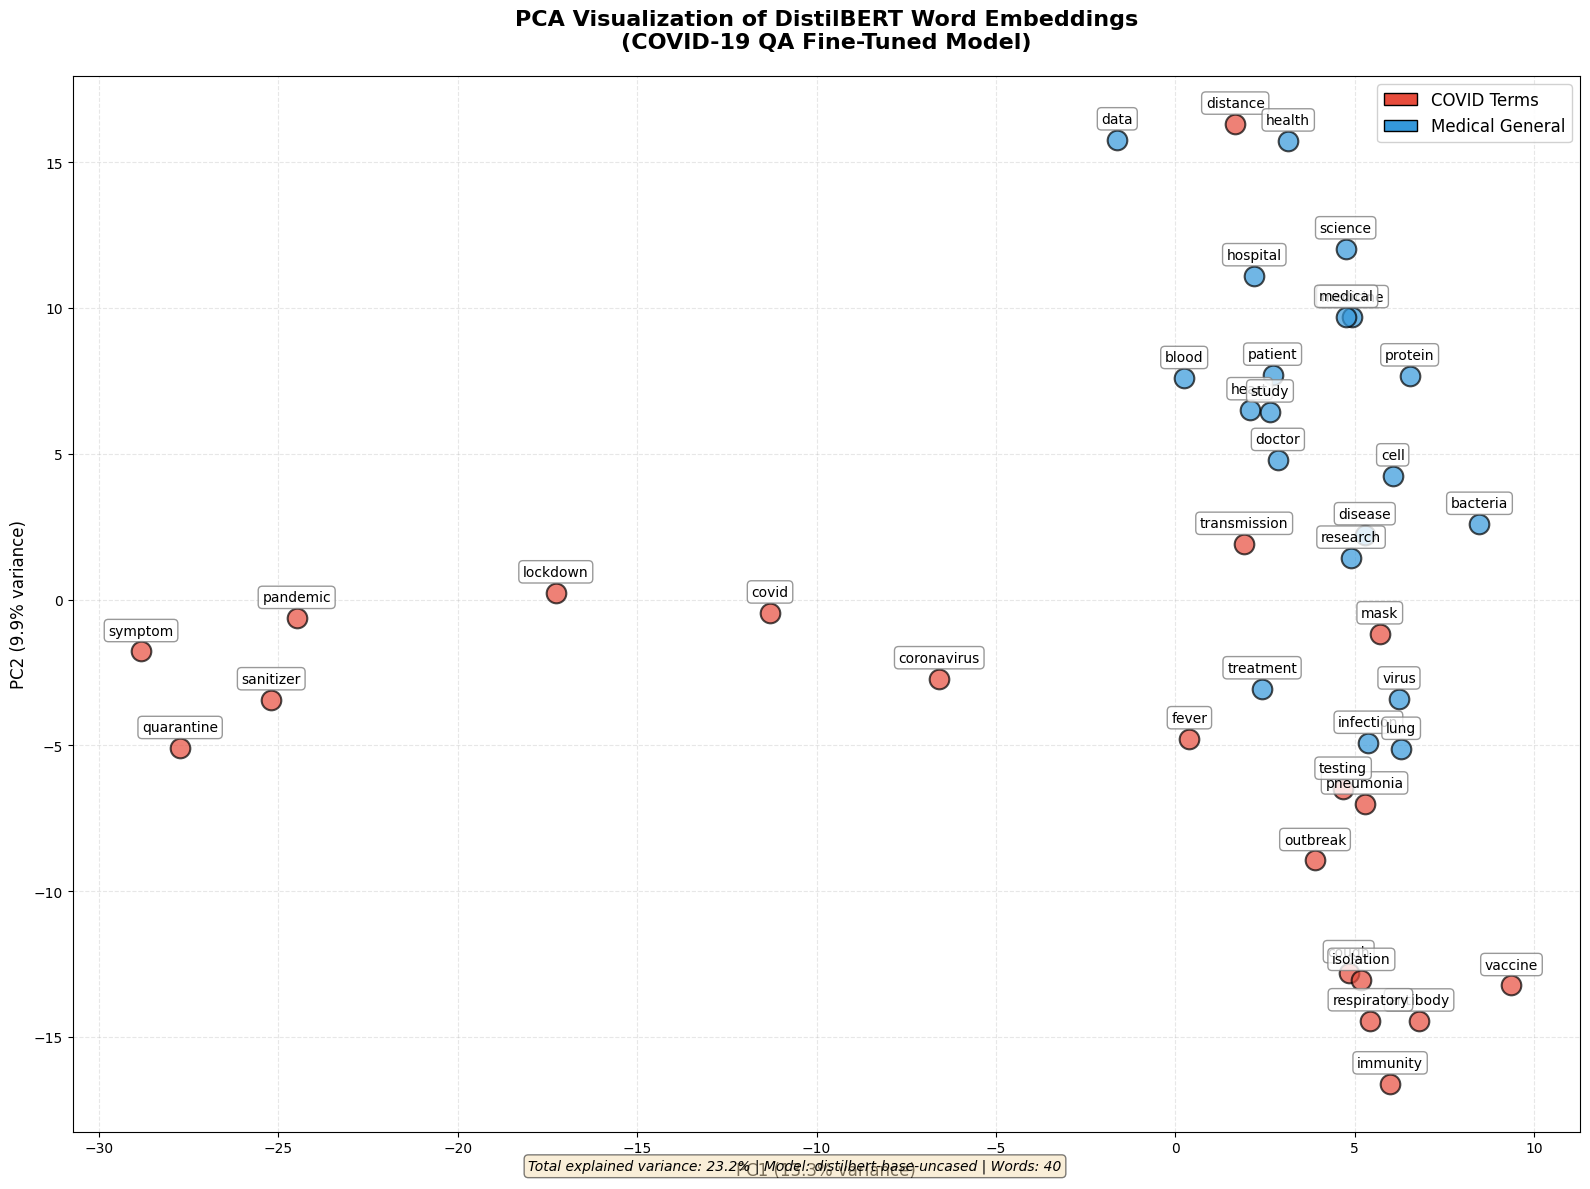


PCA Results:
  PC1 explains 13.31% of variance
  PC2 explains 9.94% of variance
  Total explained: 23.25%


In [15]:
# Apply PCA to reduce dimensions to 2D
# Standardize the embeddings
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(word_embeddings)

# Apply PCA
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(embeddings_scaled)

# Create visualization
plt.figure(figsize=(16, 12))

# Color mapping by category
categories = {
    "COVID Terms": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
    "Medical General": [20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39],
}

colors = {
    "COVID Terms": "#e74c3c",  # Red
    "Medical General": "#3498db",  # Blue
}

# Plot each word
for i, word in enumerate(covid_words):
    # Determine category
    cat = "COVID Terms" if i < 20 else "Medical General"

    plt.scatter(
        embeddings_2d[i, 0],
        embeddings_2d[i, 1],
        c=colors[cat],
        s=200,
        alpha=0.7,
        edgecolors='black',
        linewidth=1.5,
        zorder=5
    )

    # Add word labels with slight offset
    plt.annotate(
        word,
        (embeddings_2d[i, 0], embeddings_2d[i, 1]),
        fontsize=10,
        ha='center',
        va='bottom',
        xytext=(0, 10),
        textcoords='offset points',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'),
        zorder=10
    )

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[cat], edgecolor='black', label=cat) for cat in colors]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12, framealpha=0.9)

# Styling
plt.title("PCA Visualization of DistilBERT Word Embeddings\n(COVID-19 QA Fine-Tuned Model)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)", fontsize=12)
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)", fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

# Add explained variance info
total_var = sum(pca.explained_variance_ratio_) * 100
plt.figtext(0.5, 0.02, f"Total explained variance: {total_var:.1f}% | Model: {model_name} | Words: {len(covid_words)}",
            ha='center', fontsize=10, style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.savefig('pca_word_embeddings.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nPCA Results:")
print(f"  PC1 explains {pca.explained_variance_ratio_[0]*100:.2f}% of variance")
print(f"  PC2 explains {pca.explained_variance_ratio_[1]*100:.2f}% of variance")
print(f"  Total explained: {total_var:.2f}%")

Variance Analysis Plot

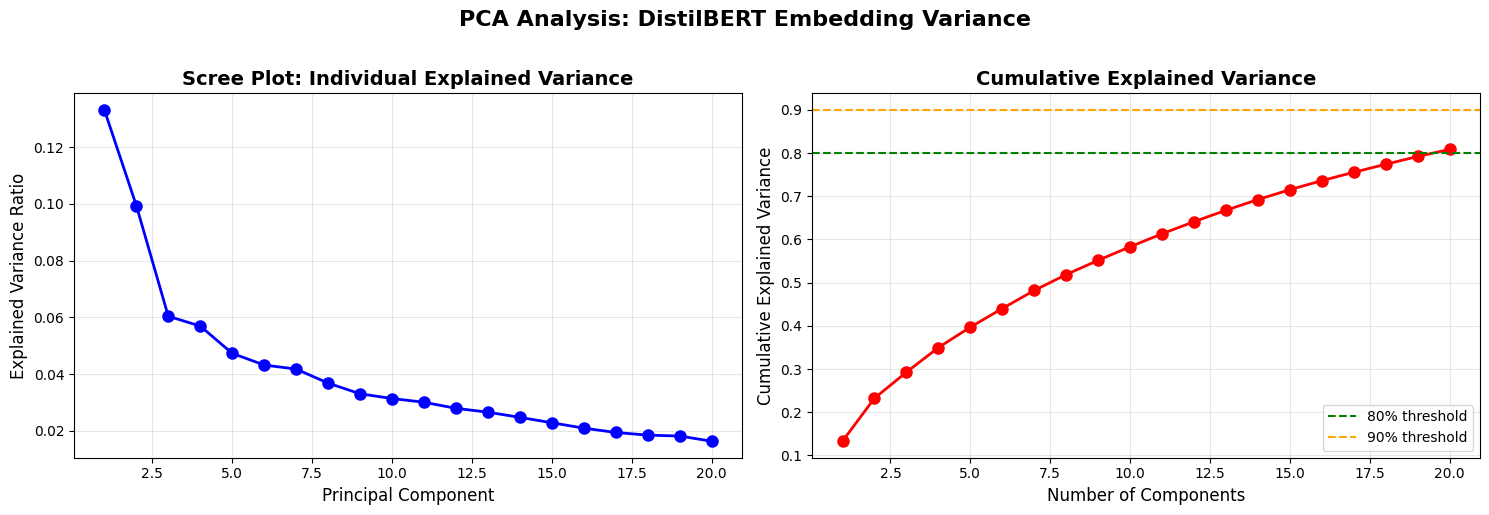

In [16]:
# Additional visualization: Explained variance plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scree plot
pca_full = PCA(n_components=min(20, len(covid_words)), random_state=42)
pca_full.fit(embeddings_scaled)

axes[0].plot(range(1, len(pca_full.explained_variance_ratio_) + 1),
         pca_full.explained_variance_ratio_, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=12)
axes[0].set_title('Scree Plot: Individual Explained Variance', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Cumulative variance
cumulative_var = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var, 'ro-', linewidth=2, markersize=8)
axes[1].axhline(y=0.8, color='g', linestyle='--', label='80% threshold')
axes[1].axhline(y=0.9, color='orange', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance', fontsize=12)
axes[1].set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA Analysis: DistilBERT Embedding Variance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pca_variance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

Similarity Heatmap

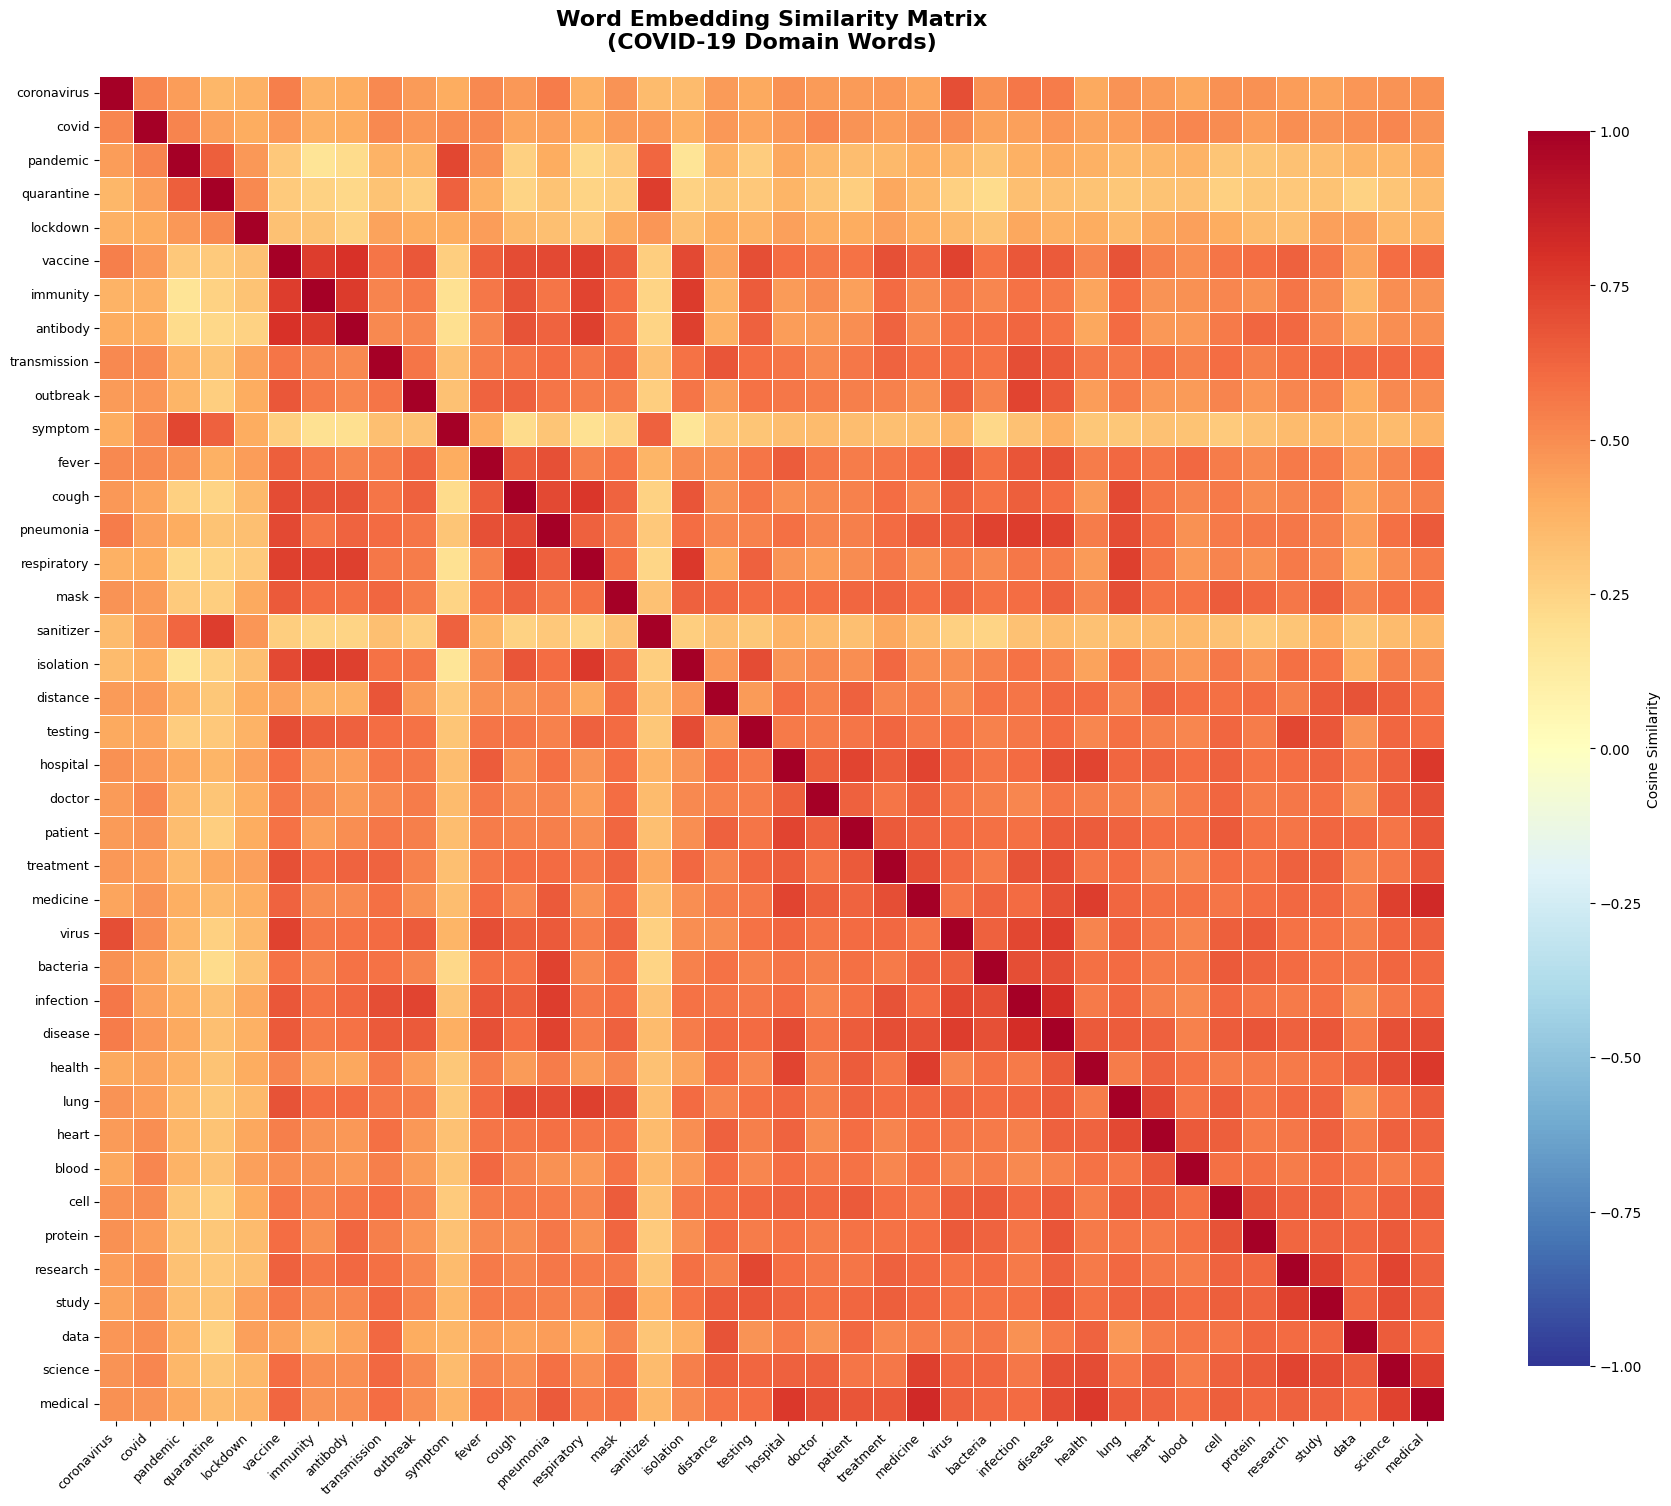

In [17]:
# Semantic similarity heatmap
from sklearn.metrics.pairwise import cosine_similarity

# Calculate cosine similarity matrix
similarity_matrix = cosine_similarity(word_embeddings)

# Create heatmap
plt.figure(figsize=(18, 16))

# Create mask for upper triangle (optional, for cleaner look)
mask = np.triu(np.ones_like(similarity_matrix, dtype=bool), k=1)

sns.heatmap(
    similarity_matrix,
    xticklabels=covid_words,
    yticklabels=covid_words,
    cmap='RdYlBu_r',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Cosine Similarity"},
    vmin=-1, vmax=1
)

plt.title('Word Embedding Similarity Matrix\n(COVID-19 Domain Words)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('embedding_similarity_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()